In [6]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patches
from cmath import rect
from matplotlib.colors import ListedColormap

import os
%matplotlib inline

Nitrogen

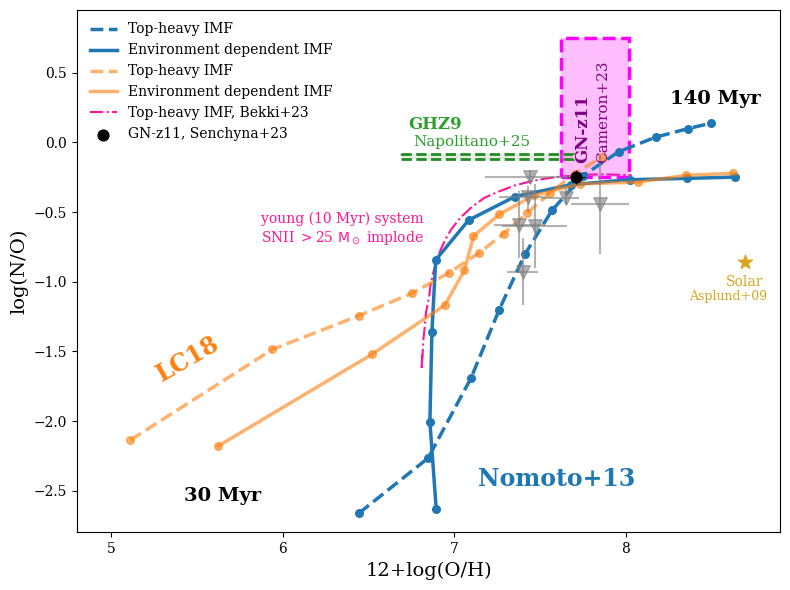

In [82]:
def load_file_paths(base_dir):
    file_paths = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file == "chemical_and_SN_evolution.txt":
                file_paths.append(os.path.join(root, file))
    return file_paths

def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

def recalculate(logNO, logOH): # Recalculate logNO and logOH
    logNO = [i - 0.86 for i in logNO]
    logOH = [i + 8.696 for i in logOH]
    return logNO, logOH

def fit(logOH, logNO): # Fit a polynomial to the data
    coefficients = np.polyfit(logOH, logNO, deg=6)
    polynomial = np.poly1d(coefficients)
    smooth_logOH = np.linspace(min(logOH[6:]), max(logOH[6:]), 500)
    smooth_logNO = polynomial(smooth_logOH)
    return smooth_logOH, smooth_logNO

def prepare_data(file_paths):
    for path in file_paths:
        data = load_data_with_names(path)
        logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
        FeH, MgH, OH = data['Gas [Fe/H]:'], data['Gas [Mg/H]:'], data['Gas [O/H]:']
        timestep = data['time step list:']
        logNO_rec, logOH_rec = recalculate(logNO, logOH)
        smooth_logOH, smooth_logNO = fit(logOH_rec, logNO_rec)
    return smooth_logOH, smooth_logNO

def plot_high_redshift_gal_data():
    CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
    # Define data points: (12+O/H, N/O, label, color, err_x, err_y, age, age_err, agn?)
    points = [
        # (8.38, -0.13, 'Mrk 996 (high density)', 0.075, 0.28),
        # (8.36, -1.43, 'Mrk 996 (low density)', 0.225, 0.14),
        # (8.03, -0.21, 'LyC', 0.06, 0.105),
        # (8.00, -0.88, 'ID150880', 0.10, 0.15),
        # ((7.15+7.67)/2, 0.20, 'UNCOvER-45924', 7.67-((7.15+7.67)/2), 0.06),
        # (8.26, -0.93, 'ID1665', 0.15, 0.15),
        # (7.92, -0.85, 'ID1746', 0.13, 0.15),
        # (7.72, -0.62, 'ID1477', 0.09, 0.11),
        # (7.75, -0.76, 'ID60001', 0.03, 0.03),
        # (7.97, -0.86, 'EXCELS-121806', 0.04, 0.10),
        # (7.90, -1.10, 'GS_3073 (low density)', 0.09, 0.12),
        # (7.59, -0.85, 'GS_9422 (tentative)', 0.06, 0),
        # (7.96, -0.67, 'ID397', 0.10, 0.14),
        (7.43, -0.39, 'RXJ2248-ID', CB_color_cycle[1], [[0.17], [0.09]] , [[0.10], [0.08]]),
        (7.65, -0.40, 'GLASS_150008', CB_color_cycle[5], [[0.14], [0.08]] , [[0.05], [0.07]]),
        (7.47, -0.6, 'A1703-zdk6', CB_color_cycle[6], [[0.19], [0.19]], [[0.3], [0.3]]),
        (7.85, -0.44, 'GN-z8-LAE', CB_color_cycle[7], [[0.17], [0.17]], [[0.36], [0.36]]),
        # (8.37, -0.01, 'CEERS_01019 (AGN)', 0.13, 0),
        (7.38, -0.59, 'GN-z9p4', CB_color_cycle[3], [[0.15], [0.15]], [[0.24], [0.24]]),
        # (7.49, -0.93, 'GS-z9-0 light-weighted', 0.11, 0.37),
        (7.4, -0.93, 'GS-z9-0', CB_color_cycle[2], [[0.09], [0.09]], [[0.24], [0.24]]),
        # ((6.69+7.69)/2, (-0.08-0.12)/2, 'GHZ9p', CB_color_cycle[2], 0, 0),
        (7.44, -0.25, 'GHZ2/GLASS-z12', CB_color_cycle[8], [[0.26], [0.24]], [[0.05], [0.05]]) 
    ]

    handles = []
    for x, y, label, color, xerr, yerr in points:
        sc = plt.scatter(x, y, color='gray', label=label, s=95, marker='v', zorder=5, alpha=0.6)
        plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', elinewidth=1.5, ecolor='gray', zorder=5, alpha=0.6)
        handles.append(sc)
    # Custom legend
    # lgd = plt.legend(handles=handles, labels=[p[2] for p in points], bbox_to_anchor=(1.08, 1), loc='upper left', fontsize=8, title="Observational Data")


def plot_Bekki_comparison():
    patha115 = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha115.csv"
    patha155 = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha155.csv"
    patha235 = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha235.csv"
    pathdwarf = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/dwarf.csv"

    a115 = np.loadtxt(patha115, delimiter=',')
    a155 = np.loadtxt(patha155, delimiter=',')
    a235 = np.loadtxt(patha235, delimiter=',')
    dwarf = np.loadtxt(pathdwarf, delimiter=',')

    BlogOHa115 = a115[:, 0]
    BlogNOa115 = a115[:, 1]
    BlogOHa155 = a155[:, 0]
    BlogNOa155 = a155[:, 1]
    BlogOHa235 = a235[:, 0]
    BlogNOa235 = a235[:, 1]
    BlogOHdwarf = dwarf[:, 0]
    BlogNOdwarf = dwarf[:, 1] 

    plt.rc('font', family='serif')
    # plt.plot(BlogOHa155, BlogNOa155, color='palevioletred', lw=1.1, label='Bekki, $\\alpha=1.55$', linestyle=':')
    plt.plot(BlogOHa115, BlogNOa115, color='deeppink', lw=1.5, label='Top-heavy IMF, Bekki+23', linestyle='-.', zorder=0)
    plt.text(6.35, -0.6, 'young (10 Myr) system', color='deeppink', ha='center', va='bottom', fontsize=10)
    plt.text(6.35, -0.75, 'SNII $>$25 $\\rm M_\odot~$implode', color='deeppink', ha='center', va='bottom', fontsize=10)
    # plt.plot(BlogOHa235, BlogNOa235, color='crimson', lw=1, label='Bekki, $\\alpha=2.35$', linestyle='--')
    # plt.plot(BlogOHdwarf, BlogNOdwarf, color='darkmagenta', lw=1, label='Bekki, dwarf', linestyle='-.')
    Xmin, Xmax = 6.69, 7.69
    Ymin, Ymax = -0.08, -0.12
    rect2 = patches.Rectangle((Xmin, Ymin), Xmax-Xmin, Ymax-Ymin,
                         linewidth=2, facecolor='darkseagreen',
                         alpha=0.25, zorder=10)
    plt.gca().add_patch(rect2)
    rect3 = patches.Rectangle((Xmin, Ymin), Xmax-Xmin, Ymax-Ymin,
                         linewidth=2, edgecolor='forestgreen', facecolor='none',
                         alpha=1, linestyle='--', zorder=10)
    plt.gca().add_patch(rect3)
    plt.text(6.89, 0.065, 'GHZ9', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold")
    plt.text(7.1, -0.05, 'Napolitano+25', color='tab:green', ha='center', va='bottom', fontsize=11)

    xmin, xmax = 7.62, 8.02
    ymin, ymax = -0.25, 0.75
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2.5, facecolor='magenta',
                         alpha=0.25, zorder=0)
    plt.gca().add_patch(rect)
    rect1 = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2.5, edgecolor='magenta', facecolor='none',
                         alpha=1, linestyle='--', zorder=0)
    plt.gca().add_patch(rect1)
    # plt.plot([7.82, 7.92], [-0.25, 0.25], color='purple', linestyle=':', linewidth=2, marker=None)
    plt.text(7.75, - 0.25 + 0.1, 'GN-z11', color='purple', ha='center', va='bottom', fontsize=12, rotation=90, weight="bold", zorder=10)
    plt.text(7.87, - 0.25 + 0.1, 'Cameron+23', color='purple', ha='center', va='bottom', fontsize=11, rotation=90, zorder=10)
    # plt.scatter(7.84, -0.38, color='black', label='GN-z11', s=30, marker='*') # from Senchyna23 https://arxiv.org/pdf/2303.04179 (gas + dust)
    plt.scatter(7.71, -0.25, color='black', label='GN-z11, Senchyna+23', s=60, marker='o', zorder=5) # gas-phase only (Senchyna23), BEAGLE line fitting
    plt.errorbar(7.71, -0.25, 0.05, 0.05, fmt='none', elinewidth=0.8, ecolor='black', zorder=5)
    plt.scatter(8.696, -0.86, color='goldenrod', s=110, marker='*')
    plt.text(8.696, -1.05, 'Solar', color='goldenrod', ha='center', va='bottom', fontsize=10)
    plt.text(8.6, -1.15, 'Asplund+09', color='goldenrod', ha='center', va='bottom', fontsize=9)
    # ax = plt.gca()
    # ax.axhline(-0.86, color='red', linestyle='--', linewidth=0.5, label='Solar')
    # ay = plt.gca()
    # ay.axvline(8.696, color='red', linestyle='--', linewidth=0.5)
    # plt.scatter(7.91, -0.2, color='red', label='GN-z11', s=30, marker='*')

  # Extend if needed
plt.rc('font', family='serif')
plt.figure(figsize=(8, 6))

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha2.1Log_SFR0.2SFEN100SFE0.0062Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
index_x=3
index_y=14

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logNO, logOH = recalculate(logNO, logOH)
    plt.scatter(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', s=30)
    plt.plot(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', lw=2.5, label='Top-heavy IMF', linestyle="--")

# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/20260703/Nomoto/imfigimfSTF0.04Log_SFR1.0SFEN15SFE0.008Z_0-4.15infall0.009/chemical_and_SN_evolution.txt")
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/imfigimfSTF0.04Log_SFR0.3SFEN100SFE0.008Z_0-4.15infall0.009/chemical_and_SN_evolution.txt")
index_x=4
index_y=14

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logNO, logOH = recalculate(logNO, logOH)
    plt.scatter(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', s=30)
    plt.plot(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:blue', lw=2.5, label='Environment dependent IMF')

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.04alpha2.1Log_SFR0.3SFEN100SFE0.0062Z_0-4.15infall0.008/chemical_and_SN_evolution.txt")
index_x=3
index_y=14

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logNO, logOH = recalculate(logNO, logOH)
    plt.scatter(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:orange', s=30, alpha=0.6)
    plt.plot(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:orange', lw=2.5, label='Top-heavy IMF', linestyle="--", alpha=0.6)

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/20260703/LCR300/imfigimfSTF0.04Log_SFR1.0SFEN15SFE0.008Z_0-4.15infall0.009/chemical_and_SN_evolution.txt")
index_x=3
index_y=14
for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logNO, logOH = data['Gas [N/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logNO, logOH = recalculate(logNO, logOH)
    plt.scatter(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:orange', s=30, alpha=0.6)
    plt.plot(logOH[index_x:index_y], logNO[index_x:index_y], color='tab:orange', lw=2.5, label='Environment dependent IMF', alpha=0.6)


plt.text(5.65, -2.6, '30 Myr', color='black', ha='center', va='bottom', fontsize=14, weight="bold")    
plt.text(8.525, 0.25, '140 Myr', color='black', ha='center', va='bottom', fontsize=14, weight="bold")       

plt.text(7.6, -2.5, 'Nomoto+13', color='tab:blue', ha='center', va='bottom', fontsize=17, weight="bold") 
plt.text(5.45, -1.75, 'LC18', color='tab:orange', ha='center', va='bottom', rotation=30, fontsize=17, weight="bold")

title='Chemical evolution models with different IMF slopes'
filename='./paper_nitrogen.pdf'
plot_Bekki_comparison()
plt.xlabel('12+log(O/H)', fontsize=14)
plt.ylabel('log(N/O)', fontsize=14)
plt.xlim(4.8, 8.9)
plt.locator_params(axis='x', nbins=8)
plt.ylim(-2.8, 0.95)
plt.locator_params(axis='y', nbins=8)
plt.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=10, frameon=False)
# lgd_obs = plot_high_redshift_gal_data()
# plt.gca().add_artist(lgd_obs)
plot_high_redshift_gal_data()
# plt.title(title, fontsize=16)
plt.savefig(filename, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
#Model 2
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.04alpha2.1Log_SFR0.3SFEN100SFE0.0062Z_0-4.15infall0.008/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.04alpha2.3Log_SFR0.2SFEN100SFE0.0061Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.02alpha3.0Log_SFR-0.3SFEN100SFE0.0085Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
# plt.text(5.55, -2.35, '20 Myr', color='black', ha='center', va='bottom', fontsize=12, weight="bold")    
# plt.text(8.575, 0.55, '110 Myr', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold") 
# plt.text(8.575, 0.20, '130 Myr', color='tab:orange', ha='center', va='bottom', fontsize=12, weight="bold")
# plt.text(8.525, -0.05, '160 Myr', color='tab:blue', ha='center', va='bottom', fontsize=12, weight="bold")         

#Model 3
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/M300_yields/20260502/imfKroupaSTF0.04alpha2.1Log_SFR0.5SFEN100SFE0.0052Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/M300_yields/20260502/imfKroupaSTF0.04alpha2.3Log_SFR0.9SFEN100SFE0.0064Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/M300_yields/20260502/imfKroupaSTF0.04alpha3.0Log_SFR-0.1SFEN100SFE0.0115Z_0-4.15infall0.0002/chemical_and_SN_evolution.txt")
# plt.text(5.55, -2.35, '20 Myr', color='black', ha='center', va='bottom', fontsize=12, weight="bold")    
# plt.text(8.575, 0.45, '90 Myr', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold") 
# plt.text(8.575, 0.20, '140 Myr', color='tab:orange', ha='center', va='bottom', fontsize=12, weight="bold")
# plt.text(8.425, -0.05, '160 Myr', color='tab:blue', ha='center', va='bottom', fontsize=12, weight="bold")  

#Model4
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha2.1Log_SFR0.2SFEN100SFE0.0062Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha2.3Log_SFR0.2SFEN100SFE0.0068Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha3.0Log_SFR0.0SFEN100SFE0.0084Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
plt.text(5.95, -2.35, '30 Myr', color='black', ha='center', va='bottom', fontsize=12, weight="bold")    
plt.text(8.575, 0.4, '90 Myr', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold") 
plt.text(8.575, 0.15, '110 Myr', color='tab:orange', ha='center', va='bottom', fontsize=12, weight="bold")
plt.text(8.525, -0.05, '120 Myr', color='tab:blue', ha='center', va='bottom', fontsize=12, weight="bold")     

Carbon

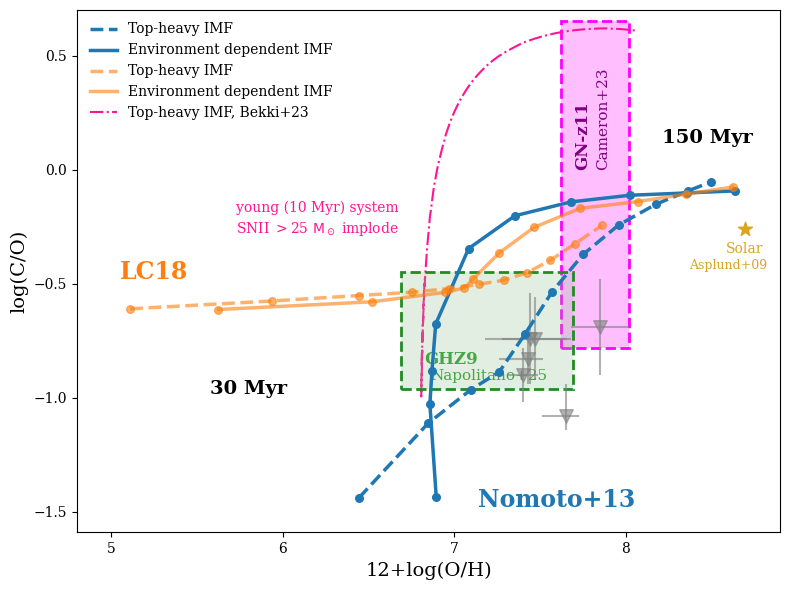

In [90]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patches
from cmath import rect
from matplotlib.colors import ListedColormap

import os
%matplotlib inline

def load_file_paths(base_dir):
    file_paths = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file == "chemical_and_SN_evolution.txt":
                file_paths.append(os.path.join(root, file))
    return file_paths

def load_data_with_names(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_dict = {}
    for i in range(len(lines)):
        line = lines[i].strip()
        if line.startswith("#"):
            row_name = line[1:].strip()
            if i + 1 < len(lines):
                data = list(map(float, lines[i + 1].strip().split()))
                data_dict[row_name] = data
    return data_dict

def recalculate(logCO, logOH):
    logCO = [i - 0.26 for i in logCO]
    logOH = [i + 8.696 for i in logOH]
    return logCO, logOH

def plot_Bekki_comparison():
    path = "/Users/adriana_work/Desktop/galIMF/Bekki paper stolen plots/alpha115_carbon.txt"
    data = np.loadtxt(path, delimiter=',')
    OH = data[:, 0]
    CO = data[:, 1]
    plt.plot(OH, CO, color='deeppink', lw=1.5, label='Top-heavy IMF, Bekki+23', linestyle='-.', zorder=0)
    plt.text(6.2, -0.2, 'young (10 Myr) system', color='deeppink', ha='center', va='bottom', fontsize=10)
    plt.text(6.2, -0.3, 'SNII $>$25 $\\rm M_\odot~$implode', color='deeppink', ha='center', va='bottom', fontsize=10)

def plot_Cameron_carbon():
    xmin, xmax = 7.62, 8.02
    ymin, ymax = -0.78, 0.65
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, facecolor='magenta',
                         alpha=0.25, zorder=0)
    plt.gca().add_patch(rect)
    rect1 = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, edgecolor='magenta', facecolor='none',
                         alpha=1, linestyle='--', zorder=0)
    plt.gca().add_patch(rect1)
    # plt.plot([7.82, 7.92], [-0.25, 0.25], color='purple', linestyle=':', linewidth=2, marker=None)
    plt.text(7.75, 0, 'GN-z11', color='purple', ha='center', va='bottom', fontsize=12, rotation=90, weight="bold")
    plt.text(7.87, 0, 'Cameron+23', color='purple', ha='center', va='bottom', fontsize=11, rotation=90)

def plot_high_redshift_data_Ji25():
    # Define data points: (12+O/H, C/O, label, color, err_x, err_y, z)
    CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
    points = [
        # (8.38, -, 'Mrk 996 (high density)', cmap(0), 0.075, 0.28),
        # (8.36, -0.22, 'Mrk 996 (low density)', 0.225, 0.25, 0.00544),
        # (8.03, -0.51, 'LyC (high density)', 0.06, 0.05, 2.37),
        # # (8.00, -, 'ID150880', cmap(4), 0.10, 0.15),
        # ((7.15+7.67)/2, -0.06, 'UNCOvER-45924', 7.67-((7.15+7.67)/2), 0.055, 4.4655),
        # # (8.26, -, 'ID1665', cmap(6), 0.15, 0.15),
        # # (7.92, -, 'ID1746', cmap(7), 0.13, 0.15),
        # # (7.72, -, 'ID1477', cmap(8), 0.09, 0.11),
        # # (7.75, -, 'ID60001', cmap(9), 0.03, 0.03),
        # (7.97, -1.02, 'EXCELS-121806', 0.045, 0.22, 5.225),
        # (8, -0.38, 'GS_3073 (high density)', 0.115, 0.12, 5.55),
        # (7.59, -0.73, 'GS_9422 (tentative)', 0.01, 0.03, 5.943),
        # # (7.96, -0.67, 'ID397', cmap(14), 0.10, 0.14),
        (7.43, -0.83, 'RXJ2248-ID', CB_color_cycle[1], [[0.17], [0.09]] , [[0.11], [0.10]]),
        (7.65, -1.08, 'GLASS_150008', CB_color_cycle[5], [[0.14], [0.08]] , [[0.06], [0.14]]),
        (7.47, -0.74, 'A1703-zdk6', CB_color_cycle[6], [[0.19], [0.19]], [[0.18], [0.18]]),
        (7.85, -0.69, 'GN-z8-LAE', CB_color_cycle[7], [[0.17], [0.17]], [[0.21], [0.21]]),
        # (8.37, -0.36, 'CEERS_01019 (AGN)', 0.135, 0, 8.679),
        # (7.94, -1.04, 'CEERS_01019 (SF)', 0.385, 0, 8.679),
        # (7.38, -1.18, 'GN-z9p4', CB_color_cycle[3], 0.15, 0, 9.380),
        # (7.49, -0.9, 'GS-z9-0 light-weighted', 0.13, 0.26, 9.4327),
        (7.4, -0.9, 'GS-z9-0', CB_color_cycle[2], [[0.09], [0.09]], [[0.12], [0.12]]),
        (7.44, -0.74, 'GHZ2/GLASS-z12', CB_color_cycle[8], [[0.26], [0.24]], [[0.2],[0.2]])
    ]

    xmin, xmax = 6.69, 7.69
    ymin, ymax = -0.96, -0.45
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, facecolor='darkseagreen',
                         alpha=0.25, zorder=5)
    plt.gca().add_patch(rect)
    rect1 = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                         linewidth=2, edgecolor='forestgreen', facecolor='none',
                         alpha=1, linestyle='--', zorder=5)
    plt.gca().add_patch(rect1)
    # plt.plot([7.82, 7.92], [-0.25, 0.25], color='purple', linestyle=':', linewidth=2, marker=None)
    plt.text(6.98, -0.87, 'GHZ9', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold")
    plt.text(7.2, -0.935, 'Napolitano+25', color='tab:green', ha='center', va='bottom', fontsize=11)
    plt.scatter(8.696, -0.26, color='goldenrod', s=110, marker='*')
    plt.text(8.696, -0.38, 'Solar', color='goldenrod', ha='center', va='bottom', fontsize=10)
    plt.text(8.6, -0.45, 'Asplund+09', color='goldenrod', ha='center', va='bottom', fontsize=9)
    handles = []
    for x, y, label, color, xerr, yerr in points:
        sc = plt.scatter(x, y, color='gray', s=95, marker='v', zorder=5, alpha=0.6)
        plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', elinewidth=1.5, ecolor='gray', zorder=5, alpha=0.6)
        handles.append(sc)


colours = colors = plt.get_cmap('tab10').colors  # Extend if needed
plt.rc('font', family='serif')
plt.figure(figsize=(8, 6))

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha2.1Log_SFR0.2SFEN100SFE0.0062Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
index_x = 3
index_y = 14

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logCO, logOH = data['Gas [C/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logCO, logOH = recalculate(logCO, logOH)
    # smooth_logOH, smooth_logNO = fit(logOH, logNO)
    # plt.plot(smooth_logOH[index_x:index_y], smooth_logNO[index_x:index_y], color=colors[i % len(colors)], lw=0.8, label=label)
    plt.scatter(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', s=30, zorder=10)
    plt.plot(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', lw=2.5, label='Top-heavy IMF', linestyle="--", zorder=10)

# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/20260703/Nomoto/imfigimfSTF0.04Log_SFR1.0SFEN15SFE0.008Z_0-4.15infall0.009/chemical_and_SN_evolution.txt")
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/paper/nomoto/imfigimfSTF0.04Log_SFR0.3SFEN100SFE0.008Z_0-4.15infall0.009/chemical_and_SN_evolution.txt")
index_x = 4
index_y = 14

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logCO, logOH = data['Gas [C/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logCO, logOH = recalculate(logCO, logOH)
    # smooth_logOH, smooth_logNO = fit(logOH, logNO)
    # plt.plot(smooth_logOH[index_x:index_y], smooth_logNO[index_x:index_y], color=colors[i % len(colors)], lw=0.8, label=label)
    plt.scatter(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', s=30, zorder=10)
    plt.plot(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:blue', lw=2.5, label='Environment dependent IMF', zorder=10)

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.04alpha2.1Log_SFR0.3SFEN100SFE0.0062Z_0-4.15infall0.008/chemical_and_SN_evolution.txt")
index_x = 3
index_y = 14

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logCO, logOH = data['Gas [C/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logCO, logOH = recalculate(logCO, logOH)
    # smooth_logOH, smooth_logNO = fit(logOH, logNO)
    # plt.plot(smooth_logOH[index_x:index_y], smooth_logNO[index_x:index_y], color=colors[i % len(colors)], lw=0.8, label=label)
    plt.scatter(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:orange', s=30, alpha=0.6, zorder=10)
    plt.plot(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:orange', lw=2.5, label='Top-heavy IMF', linestyle="--", alpha=0.6, zorder=10)

file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/20260703/LCR300/imfigimfSTF0.04Log_SFR1.0SFEN15SFE0.008Z_0-4.15infall0.009/chemical_and_SN_evolution.txt")
index_x = 3
index_y = 14

for i, path in enumerate(file_paths):
    data = load_data_with_names(path)
    logCO, logOH = data['Gas [C/O]:'], data['Gas [O/H]:']
    time_steps = data['time step list:']
    stellar_ages = np.log10(time_steps)
    logCO, logOH = recalculate(logCO, logOH)
    # smooth_logOH, smooth_logNO = fit(logOH, logNO)
    # plt.plot(smooth_logOH[index_x:index_y], smooth_logNO[index_x:index_y], color=colors[i % len(colors)], lw=0.8, label=label)
    plt.scatter(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:orange', s=30, alpha=0.6, zorder=10)
    plt.plot(logOH[index_x:index_y], logCO[index_x:index_y], color='tab:orange', lw=2.5, label='Environment dependent IMF', alpha=0.6, zorder=10)

plt.text(5.8, -1, '30 Myr', color='black', ha='center', va='bottom', fontsize=14, weight="bold")    
plt.text(8.475, 0.1, '150 Myr', color='black', ha='center', va='bottom', fontsize=14, weight="bold")

plt.text(7.6, -1.5, 'Nomoto+13', color='tab:blue', ha='center', va='bottom', fontsize=17, weight="bold") 
plt.text(5.25, -0.5, 'LC18', color='tab:orange', ha='center', va='bottom', fontsize=17, weight="bold")

filename='./paper_carbon.pdf'
plt.xlabel('12+log(O/H)', fontsize=14)
plt.ylabel('log(C/O)', fontsize=14)
plt.locator_params(axis='x', nbins=8)
plt.locator_params(axis='y', nbins=8)
plt.xlim(4.8, 8.9)
plt.ylim(-1.59, 0.7)
# plt.title(title, fontsize=12)
plot_Cameron_carbon()
plot_Bekki_comparison()
plot_high_redshift_data_Ji25()
plt.legend(bbox_to_anchor=(0, 1), loc="upper left", fontsize=10, frameon=False)
plt.savefig(filename, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
#Model 2
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.04alpha2.1Log_SFR0.3SFEN100SFE0.0062Z_0-4.15infall0.008/chemical_and_SN_evolution.txt")
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.04alpha2.3Log_SFR0.2SFEN100SFE0.0061Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/final_results/imfKroupaSTF0.02alpha3.0Log_SFR-0.3SFEN100SFE0.0085Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
plt.text(4.9, -0.73, '20 Myr', color='black', ha='center', va='bottom', fontsize=12, weight="bold")    
plt.text(8.575, 0.02, '110 Myr', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold") 
plt.text(8.575, -0.09, '130 Myr', color='tab:orange', ha='center', va='bottom', fontsize=12, weight="bold")
plt.text(8.475, -0.2, '150 Myr', color='tab:blue', ha='center', va='bottom', fontsize=12, weight="bold")      

#Model 3
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/M300_yields/20260502/imfKroupaSTF0.04alpha2.1Log_SFR0.5SFEN100SFE0.0052Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/M300_yields/20260502/imfKroupaSTF0.04alpha2.3Log_SFR0.9SFEN100SFE0.0064Z_0-4.15infall0.0008/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/M300_yields/20260502/imfKroupaSTF0.04alpha3.0Log_SFR-0.1SFEN100SFE0.0115Z_0-4.15infall0.0002/chemical_and_SN_evolution.txt")
# plt.text(5.7, -0.73, '20 Myr', color='black', ha='center', va='bottom', fontsize=12, weight="bold")    
# plt.text(8.575, 0.03, '190 Myr', color='tab:blue', ha='center', va='bottom', fontsize=12, weight="bold") 
# plt.text(8.6, -0.06, '150 Myr', color='tab:orange', ha='center', va='bottom', fontsize=12, weight="bold")
# plt.text(8.52, -0.15, '90 Myr', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold")       

#Model4
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha2.1Log_SFR0.2SFEN100SFE0.0062Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha2.3Log_SFR0.2SFEN100SFE0.0068Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
# file_paths = glob.glob("/Users/adriana_work/Desktop/galIMF/simulation_results_from_galaxy_evol/Nomoto_sup_agb/20260502/imfKroupaSTF0.04alpha3.0Log_SFR0.0SFEN100SFE0.0084Z_0-4.15infall0.002/chemical_and_SN_evolution.txt")
# plt.text(6.8, -1.4, '30 Myr', color='black', ha='center', va='bottom', fontsize=12, weight="bold")    
# plt.text(8.25, 0.03, '100 Myr', color='tab:green', ha='center', va='bottom', fontsize=12, weight="bold") 
# plt.text(8.6, -0.02, '130 Myr', color='tab:orange', ha='center', va='bottom', fontsize=12, weight="bold")
# plt.text(8.62, -0.15, '140 Myr', color='tab:blue', ha='center', va='bottom', fontsize=12, weight="bold")       



Mass budget